In [1]:
# ============================================================
# ライブラリの import
# ============================================================
import torch
import torch.nn as nn          # 層の定義（Linear, ReLU など）
import torch.optim as optim    # 最適化（Adam など）
from torch.utils.data import random_split

from torch.utils.data import DataLoader          # ミニバッチでデータを流す
# from torchvision import datasets, transforms     # MNIST と前処理

#  FashionMNIST は モジュールではなくクラス
# "from torchvision.datasets.FashionMNIST import datasets,transforms

# いったんこっちを採用
from torchvision import datasets, transforms
# 使うとき: datasets.FashionMNIST(...)

# from torchvision.datasets import FashionMNIST
# from torchvision import transforms
# 使うとき: FashionMNIST(...)

In [2]:
# ============================================================
# デバイス選択（GPU があれば cuda、なければ cpu）
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
# 今の環境は CPU でも MNIST MLP なら数分で学習できる

device: cuda


In [3]:
import os
import random

import numpy as np
import torch

# 決定的 CUDA のため（カーネル起動前に置くのが理想。変更後は Restart & Run All）
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

SEED = 0


def set_seed(seed: int = SEED) -> None:
    """
    実験の再現性を高めるため、各乱数源を固定する。
    学習セル・Fine-tuning セルの直前でも呼び直すこと。
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 未対応オペレータがあっても止めず警告だけ
    torch.use_deterministic_algorithms(True, warn_only=True)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def make_torch_generator(seed: int = SEED) -> torch.Generator:
    """DataLoader(shuffle=True) 用のシード付き Generator"""
    g = torch.Generator()
    g.manual_seed(seed)
    return g


set_seed(SEED)
print(f"SEED={SEED} (reproducibility)")


SEED=0 (reproducibility)


In [4]:
from pathlib import Path


def find_project_root(start_path: Path) -> Path:
    """
    上位ディレクトリを探索し、
    .gitが存在する場所をプロジェクトルートとして返す。
    """
    start_path = start_path.resolve()

    for candidate in [
        start_path,
        *start_path.parents,
    ]:
        if (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError(
        "プロジェクトルートを特定できませんでした。"
        "上位ディレクトリに.gitが存在するか確認してください。"
    )


# プロジェクトルートを取得
project_root = find_project_root(Path.cwd())

# 実験を識別する名前
dataset_name = "20_fashion_mnist"
experiment_name = "03_mlp_svd_finetuning"

# プロジェクトルート直下へ保存する
data_dir = project_root / "data"

# NG（旧）: models は dataset 直下にフラット保存
# models_dir = (
#     project_root
#     / "models"
#     / dataset_name
# )
# OK: results と同じく experiment_name ディレクトリに分ける
models_dir = (
    project_root
    / "models"
    / dataset_name
    / experiment_name
)

results_dir = (
    project_root
    / "results"
    / dataset_name
    / experiment_name
)

# 必要なディレクトリを作成する
for directory in [
    data_dir,
    models_dir,
    results_dir,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(f"project_root: {project_root}")
print(f"data_dir:     {data_dir}")
print(f"models_dir:   {models_dir}")
print(f"results_dir:  {results_dir}")

project_root: D:\dev\nn-compression-svd-dmrg
data_dir:     D:\dev\nn-compression-svd-dmrg\data
models_dir:   D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\03_mlp_svd_finetuning
results_dir:  D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\03_mlp_svd_finetuning


In [5]:
# ============================================================
# FashionMNIST データの準備
# ============================================================

set_seed(SEED)

# ToTensor(): 画像を [0,1] の float テンソルに変換
#   元: PIL Image (28×28) → 後: Tensor (1, 28, 28)
transform = transforms.Compose([
    transforms.ToTensor()
])

# root="./data" にダウンロード＆キャッシュされる
train_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=transform
)

train_dataset, validation_dataset, validation_dataset_rank = random_split(
    train_dataset,
    [50_000, 5_000, 5_000],
    generator=make_torch_generator(SEED),
)

test_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=transform
)

# DataLoader: データをミニバッチに分割して渡す
validation_loader = DataLoader(
    validation_dataset,
    batch_size=64,   # 1回の更新で使う枚数
    shuffle=False    # 評価用データを並べ替える必要はない。
)

# DataLoader: データをミニバッチに分割して渡す
validation_loader_rank= DataLoader(
    validation_dataset_rank,
    batch_size=64,   # 1回の更新で使う枚数
    shuffle=False    # 評価用データを並べ替える必要はない。
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False    # 評価時は混ぜなくてよい
)

# DataLoader: データをミニバッチに分割して渡す
# NG（旧）: shuffle=True なのに generator なし → 実行ごとに学習順が変わる
# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# OK: generator でシャッフル順を固定
train_loader = DataLoader(
    train_dataset,
    batch_size=64,   # 1回の更新で使う枚数
    shuffle=True,    # 学習時は順番を混ぜる
    generator=make_torch_generator(SEED),
)

print("train size:", len(train_dataset))  # 55000（分けた）
print("validation size:", len(validation_dataset))  # 5000（分けた）
print("test size:", len(test_dataset))    # 10000（規定値）

train size: 50000
validation size: 5000
test size: 10000


In [6]:
# ============================================================
# MLP の定義（圧縮前のベースライン構造）
# ============================================================
# 784 → 512 → 256 → 10
# あとで fc1 / fc2 の重みを SVD で圧縮する想定
class MNISTMLP(nn.Module):
    # 
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 512)  # ここが圧縮の主な対象候補
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(256, 10)   # 出力は 10 クラス（数字 0〜9）

    def forward(self, x):
        # x shape: (batch_size, 1, 28, 28)

        #-1→ 残りの次元を自動で計算する。
        # if self.training:
        # ...
        # else:
        # ...
        # 画像を1次元ベクトルに変換（MLP はベクトル入力）
        # x.size(0)→ バッチサイズ(64)をそのまま残す。
        x = x.view(x.size(0), -1)  # (batch_size, 784)

        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)  # logits（ソフトマックス前の生スコア）を返す

        return x

In [7]:
# ============================================================
# モデル・損失関数・最適化手法の準備
# ============================================================
set_seed(SEED)  # 重み初期化を固定


# MNISTMLP() で、さっき定義したニューラルネット本体を作っています。
# .to(device) は、そのモデルをGPU に移しています。
model = MNISTMLP().to(device)

# 多クラス分類なので CrossEntropyLoss
# （内部で log_softmax + NLLLoss をやるので、モデル出力は logits のまま）
criterion = nn.CrossEntropyLoss()

# Adam: 学習率 0.001 はよく使う初期値
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

MNISTMLP(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


In [8]:
# ============================================================
# 学習 1 epoch = 「全データを1回見て、間違いを直す」
# ============================================================
# 1バッチごとのやること（これが学習の本体）:
#   1. 画像を入れる → 予測が出る
#   2. 正解と比べて loss（間違い）を計算
#   3. 「どの重みをどう直せばいいか」を計算（backward）
#   4. 重みを少し更新（step）
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    # model.train() は nn.Module が持っている仕組み
    # モデル自身とその子モジュールの training 状態を True にします
    # 今はなくてもあっても変わらない
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:  # 64枚ずつ取り出す
        images = images.to(device)
        labels = labels.to(device)

        # PyTorch は勾配を足し込むので、毎回リセット
        optimizer.zero_grad()            # ① 前回の修正メモを消す

        # forwardを使って計算している
        # outputs = model.forward(images)と同じ
        outputs = model(images)          # ② 予測（10クラス分のスコア）

        loss = criterion(outputs, labels)  # ③ 間違いの大きさ

        # 誤差逆伝播をして勾配を作る
        # forwardで計算したlossをbackwardで勾配を計算する
        loss.backward()                  # ④ どこを直せばいいか計算

        # backwardで計算した勾配をstepで更新する
        optimizer.step()                 # ⑤ 重みを少し直す

        # loss.item() はそのバッチの平均損失
        # images.size(0) を掛けるのは、64枚分の損失の合計っぽいものに直して、
        # あとで全体平均を取るため
        total_loss += loss.item() * images.size(0)

        # 0~9での各スコアを比較して１番大きいものをとる→これが予測
        predicted = torch.argmax(outputs, dim=1)  # 一番高いスコアの数字

        # 予測と正解を比較して、正解している数を数える
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total   # 平均 loss
    accuracy = correct / total      # 正解率

    return avg_loss, accuracy

In [9]:
# ============================================================
# テストデータでの評価（学習はしない）
# ============================================================
def evaluate(model, loader, criterion, device):
    model.eval()  # 評価モード

    total_loss = 0.0
    correct = 0
    total = 0

    # 評価時は勾配不要 → メモリ節約・高速化
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # 画像をモデルへ入力して、各クラスのスコアを取得します。
            #tensor([-1.2,0.3,2.7,-0.8,1.1,-2.0,0.4,-1.5,0.2,-0.7,])
            # logitと呼ばれる未正規化スコアです。
            outputs = model(images)
            # 交差エントロピーloss、これは平均値で出る
            loss = criterion(outputs, labels)
            # 平均値で出るので、バッチ内の件数を掛けて、バッチ全体のloss合計
            total_loss += loss.item() * images.size(0)

            #outputsは各画像について10クラス分のスコアを持っています。
            #dim=1は、クラス方向に最大値を探すという意味です。
            predicted = torch.argmax(outputs, dim=1)
            # 予測と正解を比較して、正解している数を数える
            correct += (predicted == labels).sum().item()
            #
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [10]:
set_seed(SEED)  # 学習開始前に乱数を固定

import copy

MAX_EPOCHS = 50
PATIENCE = 5
MIN_DELTA = 1e-4

best_validation_loss = float("inf")
best_epoch = None
best_model_state = None
no_improvement_count = 0
results = []
for epoch in range(MAX_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
    )

    validation_loss, validation_acc = evaluate(
        model,
        validation_loader,
        criterion,
        device,
    )


    # epoch終了後の同じモデルでTrainを再評価
    train_eval_loss, train_eval_acc = evaluate(
        model,
        train_loader,
        criterion,
        device,
    )


    # バリデーションデータの損失が改善したかどうかを確認
    if best_validation_loss - MIN_DELTA > validation_loss:
        # バリデーションデータの損失が改善した場合
        best_validation_loss = validation_loss 
        best_epoch = epoch+1
        # モデルの重みやバイアスなど、学習済みパラメータの辞書
        # copyはmodel.state_dict()が変わっても大丈夫なように
        best_model_state = copy.deepcopy(model.state_dict())
        no_improvement_count = 0
    else:
        # バリデーションデータの損失が改善しなかった場合
        no_improvement_count += 1

    row = {
        "epoch": epoch+1,
        "train_acc":train_eval_acc,
        "train_loss": train_eval_loss,
        "validation_loss": validation_loss,
        "validation_acc": validation_acc,
    }
    results.append(row)

    # バリデーションデータの損失が規定回数改善しなかった場合
    if no_improvement_count >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break
    

# best_model_stateをmodelへ読み込む 
model.load_state_dict(best_model_state)
baseline_state = copy.deepcopy(model.state_dict())
# 最良重みに戻した後でTestデータを評価する
#test_loss, test_acc = evaluate(
#    model,
#    test_loader,
#    criterion,
#    device,
#)
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_validation_loss:.4f}")
#rint(f"Test loss: {test_loss:.4f}")
#print(f"Test accuracy: {test_acc:.4f}")


Early stopping at epoch 16
Best epoch: 11
Best validation loss: 0.3010


In [11]:
# ============================================================
# SVD（学習の外で、重み行列 W を分解する）
# ============================================================
# W ≈ U_r @ diag(S_r) @ Vh_r
#   U_r : 左特異ベクトル（out × r）
#   S_r : 特異値（r,）← 対角行列の対角成分だけ
#   Vh_r: 右特異ベクトル（r × in）
def SVD(W, r):
    """重み行列 W を rank r で打ち切った SVD を返す"""
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    U_r = U[:, :r]   # 上位 r 列だけ残す
    S_r = S[:r]      # 上位 r 個の特異値
    Vh_r = Vh[:r, :] # 上位 r 行だけ残す

    return U_r, S_r, Vh_r

In [12]:
# ============================================================
# 1層を2層に分けて計算コストを削減する
# ============================================================
# 元: Linear(in → out)
# 後: Linear(in → r, bias=False) + Linear(r → out, bias=True)
#
# 対応:
#   first.weight  = Vh_r
#   second.weight = U_r @ diag(S_r)
#   second.bias   = 元の bias
def devidetwolayer(layer,r):
    # 中間次元と低ランク数はいっしょにすべき？
    # → ここでは中間次元 = rank r として分解している
    U_r, S_r, Vh_r = SVD(layer.weight.detach(),r)  # detach: 勾配グラフから外す
    first_layer = nn.Linear(layer.in_features, r, bias=False)  # 中間次元 r、bias は不要
    second_layer = nn.Linear(r, layer.out_features, bias=True)  # 最終出力、bias はここに置く
    with torch.no_grad():  # 重みの代入時は勾配を計算しない
        first_layer.weight.copy_(Vh_r)                  # (r, in)
        second_layer.weight.copy_(U_r @ torch.diag(S_r))  # (out, r)
        second_layer.bias.copy_ (layer.bias.data)      # 元の bias をそのまま
    # 新規 Linear は CPU 上で作られるので、元の層と同じ device へ移す
    # 元の layer.weight がいる device を見て、新しく作った first_layer と second_layer を
    # 同じ場所に移してから返す、
    return nn.Sequential(first_layer,second_layer).to(layer.weight.device)


In [13]:
# ============================================================
# 2層に分解しせず、SVDを適用したモデルで評価
# ============================================================
# one_layer_svd_mode の骨格だけ作り、各 fc を「学習済み model の圧縮版」で差し替える
# 今は使ってない

def make_one_layer_svd_model(model,r1,r2):
    one_layer_svd_model = MNISTMLP().to(device)
    # *は関数の結果を分解して渡す
    one_layer_svd_model.fc1 = RebuildSVD(*SVD(model.fc1.weight.detach(),r1),model.fc1)
    # fc2: 512→256
    one_layer_svd_model.fc2 = RebuildSVD(*SVD(model.fc2.weight.detach(),r2),model.fc2)
    # fc3: 256→10（もともと小さい層）
    #one_layer_svd_mode.fc3 = RebuildSVD(*SVD(model.fc3.weight.detach(),r3),model.fc3)
    one_layer_svd_model.fc3 =model.fc3

    return one_layer_svd_model

In [14]:
# ============================================================
# 2層に分解し、SVDを適用したモデルで評価
# ============================================================
# two_layer_svd_model の骨格だけ作り、各 fc を「学習済み model の圧縮版」で差し替える

def make_two_layer_svd_model(model,r1,r2):
    two_layer_svd_model = MNISTMLP().to(device)
    # modelに近似したものを入れる（rank が小さいほど圧縮↑）
    two_layer_svd_model.fc1 = devidetwolayer(model.fc1,r1)
    two_layer_svd_model.fc2 = devidetwolayer(model.fc2,r2)
    #two_layer_svd_model.fc3 = devidetwolayer(model.fc3,r3)
    two_layer_svd_model.fc3 = model.fc3

    return two_layer_svd_model

In [15]:
# ============================================================
# MACs(Multiply-Accumulate Operations（乗算加算演算)
# ============================================================
# 1サンプルあたりの計算量の理論値
# Linear(in→out) ≈ in * out
# 圧縮後2層 ≈ in*r + r*out
def linear_macs(layer):
    #Linear層の1サンプル当たりのMACs
    return layer.in_features * layer.out_features

def compressed_linear_macs(in_features, out_features, rank):
    #SVD後の2層LinearのMACs
    return in_features * rank + rank * out_features

def MACs(model, r1, r2, verbose=True):
    baseline_macs = (
        linear_macs(model.fc1)
        + linear_macs(model.fc2)
        + linear_macs(model.fc3)
    )

    compressed_macs = (
        compressed_linear_macs(784, 512, r1)
        + compressed_linear_macs(512, 256, r2)
        + linear_macs(model.fc3)
    )

    # 計算量が何割減ったか
    compute_reduction_rate = 1.0 - compressed_macs / baseline_macs

    if verbose:
        print("Baseline MACs:", baseline_macs)
        print("Compressed MACs:", compressed_macs)
        print(f"Compute reduction: {compute_reduction_rate:.2%}")

    # グラフ用には compressed_macs を主に使う
    return baseline_macs, compressed_macs, compute_reduction_rate


In [16]:
# ============================================================
# 精度の低下量（圧縮のトレードオフ）
# ============================================================
# test_acc     : 圧縮前（学習直後）
# new_test_acc : 圧縮後

def accuracy_drop(test_acc, new_test_acc, verbose=True):
    drop = test_acc - new_test_acc
    if verbose:
        print("Baseline accuracy:", test_acc)
        print("Compressed accuracy:", new_test_acc)
        # drop は float なので、Python 標準の round を使う
        # （torch.round は Tensor 用）
        print("Accuracy drop:", round(drop, 5))
    return drop  # results やグラフ用に数値を返す

In [17]:
# ============================================================
# 実測の推論速度比較（1バッチあたりの平均時間）
# ============================================================
import time

def benchmark_inference(model,data_loader, device, warmup=10, repeats=5000):
    """1バッチ当たりの平均推論時間を測定する。"""
    # このコードでは意味ない
    # → 小さな MLP + GPU だと差が出にくい、という意味合い
    model.eval()

    images, _ = next(iter(data_loader))
    images = images.to(device)

    # ウォームアップ（初回の遅さを測りに入れない）
    # _は捨て変数で使わないの意味
    # 何回かウォームアップするけど、値は使わないよってこと
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(images)

    # GPU は非同期なので、計時前後で同期して正確に測る
    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.no_grad():
        for _ in range(repeats):
            _ = model(images)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    return elapsed / repeats  # 1回あたりの秒数

def benchmark_inference_print(model, two_layer_svd_model, test_loader, device, verbose=True):
    baseline_time = benchmark_inference(model, test_loader, device)
    two_layer_svd_model_time = benchmark_inference(two_layer_svd_model, test_loader, device)

    if verbose:
        print(f"Baseline: {baseline_time * 1000:.3f} ms/batch")
        print(f"TwolayerSVD: {two_layer_svd_model_time * 1000:.3f} ms/batch")

    # 秒 → あとで DataFrame では ms にしてもよい
    return baseline_time, two_layer_svd_model_time


In [18]:
# ============================================================
# 予測一致率 agreement
# ============================================================
# 正解ラベルとの一致（accuracy）ではなく、
# 「圧縮前モデルと同じクラスを予測した割合」を測る。
# Acc が同程度でも、別の間違い方をしていないかのチェック用。
def agreement(baseline, compressed, loader, device):
    baseline.eval()
    compressed.eval()

    agreement_count = 0
    total = 0

    # inference_mode: 勾配不要・推論専用（no_grad より少し軽い）
    with torch.inference_mode():
        # ラベルは使わないので _ で捨てる
        for images, _ in loader:
            images = images.to(device)

            # 各サンプルの予測クラス（スコア最大の次元）
            baseline_pred = baseline(images).argmax(dim=1)
            compressed_pred = compressed(images).argmax(dim=1)

            agreement_count += (
                baseline_pred == compressed_pred
            ).sum().item()
            total += images.size(0)

    return agreement_count / total  # 0〜1（1 = 完全に同じ予測）


In [19]:
# ============================================================
# logits の RMSE（出力スコアのずれ）
# ============================================================
# agreement は「最終予測クラス」だけ見るのに対し、
# こちらは 10 クラス分の生スコア（logits）全体のずれを測る。
# 予測クラスが同じでも、確信度の差が大きいと RMSE は上がる。
def logits_rmse(baseline, compressed, loader, device):
    baseline.eval()
    compressed.eval()

    squared_error_sum = 0.0
    element_count = 0

    with torch.inference_mode():
        for images, _ in loader:
            images = images.to(device)

            # argmax せず、全クラスの logits を比較する
            baseline_logits = baseline(images)       # (batch, 10)
            compressed_logits = compressed(images)   # (batch, 10)

            difference = baseline_logits - compressed_logits
            squared_error_sum += difference.square().sum().item()
            element_count += difference.numel()

    # √(平均二乗誤差) → 要素あたりの典型的なズレ
    return (squared_error_sum / element_count) ** 0.5


In [20]:
# ============================================================
# 特異値エネルギーの保持率 retained_energy
# ============================================================
# Frobenius ノルムの二乗 = 特異値の二乗和、なので
#   sum(S[:r]^2) / sum(S^2)
# は「rank r で重みのエネルギーの何割を残したか」になる。
# 1 に近いほど近似が良く、精度低下も抑えやすい目安。
def retained_energy(layer, rank):
    singular_values = torch.linalg.svdvals(
        layer.weight.detach()
    )

    return (
        singular_values[:rank].square().sum()
        / singular_values.square().sum()
    ).item()


In [21]:
# ============================================================
# パラメータ数を数える（圧縮後と比較する基準）
# ============================================================
# fc1: 784*512+512 = 401,920
# fc2: 512*256+256 = 131,328
# fc3: 256*10+10   =   2,570
# 合計             = 535,818
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

baseline_params = count_parameters(model)
print("Baseline params:", baseline_params)

def parameters_reduction(model,two_layer_svd_model):
    return 1.0 - count_parameters(two_layer_svd_model) / count_parameters(model)


Baseline params: 535818


In [22]:
# ============================================================
# rank を変えて精度・params・MACs・近さ指標を集める
# ============================================================
import itertools

r1_list = [16, 32, 64, 128,256,512]  # fc1 の候補
r2_list = [16, 32, 64, 128,256]  # fc2 の候補
rank_configs = list(itertools.product(r1_list, r2_list))

# ベースライン推論時間は1回だけ測る（ループ内で毎回やらない）
baseline_time_s = benchmark_inference(
    model, test_loader, device, warmup=20, repeats=2000
)

baseline_rank_validation_loss, baseline_rank_validation_acc = evaluate(
    model,
    validation_loader_rank,
    criterion,
    device,
)
results = []

for fc1_rank, fc2_rank in rank_configs:
    two_layer_svd_model = make_two_layer_svd_model(
        model,
        r1=fc1_rank,
        r2=fc2_rank,
    )

    two_layer_validation_loss, two_layer_validation_accuracy = evaluate(
        two_layer_svd_model,
        validation_loader_rank,
        criterion,
        device,
    )

    # verbose=False で print を抑え、戻り値だけ使う
    drop = accuracy_drop(baseline_rank_validation_acc, two_layer_validation_accuracy, verbose=False)
    # _ は「ここに何か来るけど、今回は使わない」という意味の捨て変数
    _, compressed_macs, compute_reduction = MACs(
        model, fc1_rank, fc2_rank, verbose=False
    )
    compressed_time_s = benchmark_inference(
        two_layer_svd_model, validation_loader_rank, device, warmup=5, repeats=200
    )
    retained_energy_fc1 = retained_energy(model.fc1, fc1_rank)
    retained_energy_fc2 = retained_energy(model.fc2, fc2_rank)

    row = {
        "fc1_rank": fc1_rank,
        "fc2_rank": fc2_rank,
        "parameters": count_parameters(two_layer_svd_model),
        "parameters_reduction": parameters_reduction(model,two_layer_svd_model),
        "validation_loss": two_layer_validation_loss,
        "validation_acc": two_layer_validation_accuracy,
        "accuracy_drop": drop,
        "compressed_macs": compressed_macs,
        "compute_reduction": compute_reduction,
        "baseline_time_ms": baseline_time_s * 1000,
        "compressed_time_ms": compressed_time_s * 1000,
        # 近さ指標: 予測一致率 / logits ずれ / 特異値エネルギー保持率
        "agreement": agreement(model, two_layer_svd_model,validation_loader_rank, device),
        "logits_rmse": logits_rmse(model, two_layer_svd_model,validation_loader_rank, device),
        "retained_energy_fc1": retained_energy_fc1,
        "retained_energy_fc2": retained_energy_fc2,
        "model":two_layer_svd_model
    }
    results.append(row)
   
    # 進行状況は1行だけ
    print(
        f"r1={fc1_rank:3d}, r2={fc2_rank:3d} | "
        f"Acc={two_layer_validation_accuracy:.4f} "
        f"loss={two_layer_validation_loss:.4f} "
        f"params_reduction={row['parameters_reduction']:.4f} "
        f"(drop={drop:+.4f}) | "
        f"params={row['parameters']} | "
        f"MACs={compressed_macs}|"
        f"time={compressed_time_s*1000:.3f}ms|"
        f"agreement={row['agreement']:.4f}"
    )

print(f"\n集計完了: {len(results)} 件")


r1= 16, r2= 16 | Acc=0.7176 loss=0.8583 params_reduction=0.9321 (drop=+0.1766) | params=36362 | MACs=35584|time=0.179ms|agreement=0.7534
r1= 16, r2= 32 | Acc=0.7094 loss=0.9313 params_reduction=0.9092 (drop=+0.1848) | params=48650 | MACs=47872|time=0.300ms|agreement=0.7484
r1= 16, r2= 64 | Acc=0.7016 loss=0.9496 params_reduction=0.8633 (drop=+0.1926) | params=73226 | MACs=72448|time=0.193ms|agreement=0.7388
r1= 16, r2=128 | Acc=0.7050 loss=0.9416 params_reduction=0.7716 (drop=+0.1892) | params=122378 | MACs=121600|time=0.257ms|agreement=0.7432
r1= 16, r2=256 | Acc=0.7024 loss=0.9480 params_reduction=0.5881 (drop=+0.1918) | params=220682 | MACs=219904|time=0.167ms|agreement=0.7410
r1= 32, r2= 16 | Acc=0.8718 loss=0.3646 params_reduction=0.8934 (drop=+0.0224) | params=57098 | MACs=56320|time=0.275ms|agreement=0.9308
r1= 32, r2= 32 | Acc=0.8666 loss=0.3714 params_reduction=0.8705 (drop=+0.0276) | params=69386 | MACs=68608|time=0.187ms|agreement=0.9336
r1= 32, r2= 64 | Acc=0.8676 loss=0.37

In [23]:
def GetPoint(df, column,x,y):
    """
    knee 点計算用に、端点の座標ペアを返す。"""
    # column で並べ替え（端点 = 先頭と末尾）
    df_sorted = df.sort_values(column).reset_index(drop=True)
    p = (df_sorted[x].iloc[0], df_sorted[y].iloc[0])    # 始点の座標

    return p


In [24]:
def GetEndPoint(df, column, x, y):
    """
    knee 点計算用に、端点の座標ペアを返す。

    Parameters
    ----------
    df : DataFrame
        Pareto 点など、端点を取りたい表
    column : str
        ソートに使う列名（例: "parameters"）
        この列の最小側・最大側を端点にする
    x, y : str
        座標として取り出す列名（例: "parameters", "validation_loss"）

    Returns
    -------
    p0, p1 : tuple[float, float]
        p0 = (x0, y0) 始点（column が小さい側）
        p1 = (x1, y1) 終点（column が大きい側）
        → GetLinearEquation(p0, p1) にそのまま渡せる
    """
    # column で並べ替え（端点 = 先頭と末尾）
    df_sorted = df.sort_values(column).reset_index(drop=True)

    # 行全体を取り出す（あとで x, y 列だけ抜く）
    left = df_sorted.iloc[0]    # column 最小の行
    right = df_sorted.iloc[-1]  # column 最大の行

    # 行から座標だけ取り出し、(x, y) タプルにする
    # 例: left["parameters"], left["validation_loss"] → (12345, 0.35)
    p0 = (left[x], left[y])    # 始点の座標
    p1 = (right[x], right[y])  # 終点の座標

    return p0, p1


In [25]:
def GetlinearEquation(p0,p1):
    x0,y0=p0
    x1,y1=p1
    slope=(y1-y0)/(x1-x0)
    intercept=y0-x0*slope
    return slope,intercept

In [26]:
# ============================================================
# knee 点: 端点を結ぶ直線から最も遠い点
# 後で .py 化するとき → 例: utils/pareto_knee.py にまとめる想定
# ------------------------------------------------------------
# 同じ役割の実装を2つ残す（名前を分ける。同名だと後勝ちで上書きされる）
#   GetKneePoint_loop  … 学習用・点が少ないとき（依存少）
#   GetKneePoint_numpy … 点がたくさんあるとき向け
# ノート内のデフォルト呼び出しは GetKneePoint (= loop) を使う
# ============================================================

def GetKneePoint_loop(df, slope, intercept, x, y):
    """
    【用途】Pareto 上の knee 点（ループ実装）

    - 読みやすさ・学習用。点数〜数百ならこれで十分
    - 依存: pandas のみ（numpy 不要）
    - 後で .py 化: デフォルト実装として残す想定

    Returns
    -------
    point : tuple
        (x, y) 座標
    best_dist : float
        直線からの距離
    """
    best_dist = -1.0  # 距離は常に >=0 なので、初回必ず更新される
    best_x, best_y = None, None
    denom = (slope**2 + 1) ** 0.5  # 分母は点によらないのでループ外

    for _, row in df.iterrows():
        # 点と直線 y = slope*x + intercept の距離
        dist = abs(slope * row[x] - row[y] + intercept) / denom
        if dist > best_dist:
            best_dist = dist
            best_x, best_y = row[x], row[y]

    return (best_x, best_y), best_dist


# ノート・将来モジュールの「普通に使う方」
#GetKneePoint = GetKneePoint_loop


In [27]:
import numpy as np

def GetKneePoint_numpy(df, slope, intercept, x, y):
    """
    【用途】Pareto 上の knee 点（NumPy ベクトル化実装）

    - GetKneePoint_loop と同じ定義・同じ戻り値
    - 点が数千〜と多いときの高速版候補
    - 依存: numpy
    - 後で .py 化: オプション実装として併置する想定
      （例: prefer="numpy" で切り替える、など）

    Returns
    -------
    point : tuple
        (x, y) 座標
    best_dist : float
        直線からの距離
    """
    xs = df[x].to_numpy(dtype=float)
    ys = df[y].to_numpy(dtype=float)

    # 全点まとめて距離を計算（ベクトル化）
    dist = np.abs(slope * xs - ys + intercept) / np.sqrt(slope**2 + 1)

    knee_idx = int(np.argmax(dist))  # 最大距離の位置
    knee_row = df.iloc[knee_idx]
    return (knee_row[x], knee_row[y]), float(dist[knee_idx])


saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\03_mlp_svd_finetuning\parameters_vs_validation_loss_normalize.png
pareto points: 9


,fc1_rank,fc2_rank,parameters,validation_loss,parameters_normalize,validation_loss_normalize
0,16,16,36362,0.858264,0.000000,1.000000
1,32,16,57098,0.364576,0.052224,0.118751
2,64,16,98570,0.311055,0.156673,0.023214
3,64,64,135434,0.308326,0.249516,0.018342
4,128,16,181514,0.303367,0.365571,0.009491
5,128,64,218378,0.300577,0.458414,0.004511
6,128,128,267530,0.299852,0.582205,0.003217
7,256,64,384266,0.299022,0.876209,0.001735
8,256,128,433418,0.298050,1.000000,0.000000


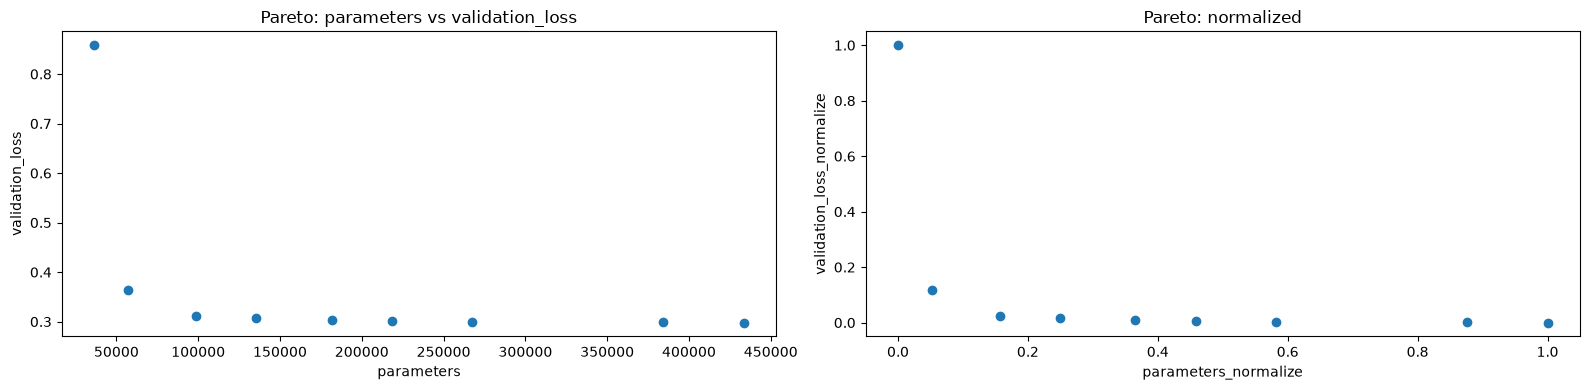

In [28]:
# ============================================================
# Pareto Frontier
# ============================================================
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

baseline_params = count_parameters(model)
df_results_for_pareto = pd.DataFrame(results)

df_pareto_view = df_results_for_pareto.copy()
# ベースラインよりパラメタ数が多いランクペアを落とす
df_pareto_view = df_pareto_view[df_pareto_view["parameters"] <= baseline_params]
# ベースラインより MACs が減っているランクペアだけ残す
df_pareto_view = df_pareto_view[df_pareto_view["compute_reduction"] > 0].copy()

# ------------------------------------------------------------
# 【元コード】うまくいかなかった書き方（学習用に残す）
# ------------------------------------------------------------
# from nt import replace  # 不要。補完などで混入したもの
#
# for index, row in df_pareto_view.iterrows():
#     # NG1: Python の and は Series の真偽を求めようとして
#     #      ValueError: The truth value of a Series is ambiguous
#     # if any(df_pareto_view["parameters"] <= row["parameters"] and
#     #        df_pareto_view["validation_loss"] <= row["validation_loss"]):
#
#     # NG2: and を & に変えても、any(Series) より Series.any() を使うべき
#     #      また括弧が無いと演算子の優先順位で意図と違う式になる
#     # if any((df_pareto_view["parameters"] <= row["parameters"])
#     #        & (df_pareto_view["validation_loss"] <= row["validation_loss"])
#     #        & (index != df_pareto_view.index)):
#
#     # NG3: iterrows 中に inplace drop すると、走査中に表が変わって
#     #      行が飛んだり KeyError になったりしやすい
#     #     df_pareto_view.drop(index=index, inplace=True)
#
#     # NG4: drop(..., replace=True) は誤り。正しくは inplace=True か代入
#     # NG5: 両方 <= だけだと「厳密に良い点」が無くても落ちる/残る判定が曖昧。
#     #      自分自身も両方 <= で True になるので、除外 or 厳密不等号が必要

# ------------------------------------------------------------
# 【修正版】Pareto frontier（parameters↓ かつ validation_loss↓ が良い）
# ある点より「両方とも同等以上、かつ少なくとも一方は厳密に良い」点が
# 1つでもあれば、その点は劣後（dominated）なので落とす
# ・& で要素ごとの AND
# ・.any() で「1つでも True か」
# ・残す index を集めて最後に一度だけ絞る（ループ中 drop しない）
# ------------------------------------------------------------
keep_indices = []
for index, row in df_pareto_view.iterrows():
    # dominated: 「row より良い（または同等で一方は厳密に良い）点」がどこにあるか
    # True の行 = row を優越している点
    dominated = (
        (df_pareto_view["parameters"] <= row["parameters"])
        & (df_pareto_view["validation_loss"] <= row["validation_loss"])
        & (
            (df_pareto_view["parameters"] < row["parameters"])
            | (df_pareto_view["validation_loss"] < row["validation_loss"])
        )
    )
    # この if は必要。
    # dominated を計算しただけでは行は消えない。
    # ・dominated.any() == True  → 誰かに負けている → 捨てる
    # ・dominated.any() == False → 誰にも負けていない → Pareto に残す
    # 自分自身は両方 < にならないので、ここでの True には含まれない
    if not dominated.any():
        keep_indices.append(index)

df_pareto_view = df_pareto_view.loc[keep_indices].copy()
df_pareto_view = df_pareto_view.sort_values("parameters").reset_index(drop=True)

scaler = MinMaxScaler()
df_pareto_view[
    ["parameters_normalize", "validation_loss_normalize"]
] = scaler.fit_transform(
    df_pareto_view[["parameters", "validation_loss"]]
)

# parameters vs validation_loss
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
ax[0].scatter(
    df_pareto_view["parameters"],
    df_pareto_view["validation_loss"],
    marker="o",
)
ax[0].set_xlabel("parameters")
ax[0].set_ylabel("validation_loss")
ax[0].set_title("Pareto: parameters vs validation_loss")

ax[1].scatter(
    df_pareto_view["parameters_normalize"],
    df_pareto_view["validation_loss_normalize"],
    marker="o",
)
ax[1].set_xlabel("parameters_normalize")
ax[1].set_ylabel("validation_loss_normalize")
ax[1].set_title("Pareto: normalized")

plt.tight_layout()
results_dir.mkdir(parents=True, exist_ok=True)
parameters_vs_validation_loss_path = (
    results_dir / "parameters_vs_validation_loss_normalize.png"
)
fig.savefig(parameters_vs_validation_loss_path, dpi=150, bbox_inches="tight")
print("saved:", parameters_vs_validation_loss_path.resolve())
print("pareto points:", len(df_pareto_view))
display(df_pareto_view[
    ["fc1_rank", "fc2_rank", "parameters", "validation_loss",
     "parameters_normalize", "validation_loss_normalize"]
].sort_values("parameters"))
plt.show()


In [29]:
p0 = GetPoint(
    df_pareto_view,
    "parameters_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)
# NG: y 列が "validation_loss"（正規化前）だと、正規化空間の端点にならない
# p1 = GetPoint(
#     df_pareto_view,
#     "validation_loss_normalize",
#     "parameters_normalize",
#     "validation_loss",
# )
p1 = GetPoint(
    df_pareto_view,
    "validation_loss_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)

p, distance = GetKneePoint_loop(
    df_pareto_view,
    *GetlinearEquation(p0, p1),
    "parameters_normalize",
    "validation_loss_normalize",
)
print("distance:", distance)
print(
    "best pair  parameters_normalize:",
    p[0],
    ", validation_loss_normalize:",
    p[1],
)

# parameters 順に並べてから「knee の前後」を取る
df_pareto_view = df_pareto_view.sort_values("parameters").reset_index(drop=True)

# knee 行の位置（0,1,2,...）
knee_mask = (
    (df_pareto_view["parameters_normalize"] == p[0])
    & (df_pareto_view["validation_loss_normalize"] == p[1])
)
knee_pos = int(df_pareto_view.index[knee_mask][0])

# NG（旧）: indices+1 は「ラベル全部に +1」で、隣行の意味にならない
#          loc[len(df)] への代入も壊れやすい
# indices = df_pareto_view.index[knee_mask]
# df_pareto_best = df_pareto_view.loc[knee_mask]
# df_pareto_best.loc[len(df_pareto_best)] = df_pareto_view.loc[indices + 1]
# df_pareto_best.loc[len(df_pareto_best)] = df_pareto_view.loc[indices - 1]

# OK: iloc で前後を含めてスライス（端なら存在する側だけ）
left = max(knee_pos - 1, 0)
right = min(knee_pos + 1, len(df_pareto_view) - 1)

# knee 本体（評価・selected_rank.csv 用）
df_pareto_knee = df_pareto_view.iloc[[knee_pos]].copy()
# knee ±1（parameters 順の前後も見たい用）
df_pareto_best = df_pareto_view.iloc[left : right + 1].copy()

print(f"knee_pos={knee_pos}, neighbors iloc[{left}:{right + 1}] (knee ±1 by parameters)")
print("knee:")
display(df_pareto_knee.drop(columns="model"))
print("knee ±1:")
display(df_pareto_best.drop(columns="model"))



distance: 0.5862092326788827
best pair  parameters_normalize: 0.05222437137330754 , validation_loss_normalize: 0.11875058138389116
knee_pos=1, neighbors iloc[0:3] (knee ±1 by parameters)
knee:


,fc1_rank,fc2_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_fc1,retained_energy_fc2,parameters_normalize,validation_loss_normalize
1,32,16,57098,0.893438,0.364576,0.8718,0.0224,56320,0.894737,0.136975,0.275393,0.9308,2.97952,0.709006,0.607805,0.052224,0.118751


knee ±1:


,fc1_rank,fc2_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_fc1,retained_energy_fc2,parameters_normalize,validation_loss_normalize
0,16,16,36362,0.932137,0.858264,0.7176,0.1766,35584,0.933493,0.136975,0.179334,0.7534,6.248245,0.549914,0.607805,0.000000,1.000000
1,32,16,57098,0.893438,0.364576,0.8718,0.0224,56320,0.894737,0.136975,0.275393,0.9308,2.979520,0.709006,0.607805,0.052224,0.118751
2,64,16,98570,0.816038,0.311055,0.8886,0.0056,97792,0.817225,0.136975,0.188748,0.9616,1.592894,0.837559,0.607805,0.156673,0.023214


In [30]:
# ============================================================
# Fine-tuning（knee ±1 の最大3モデル）
# 注意:
# この結果は rank 選択には使用しない。
# rank 選択は Pareto frontier + knee ±1 で完結させる。
# ============================================================

# ------------------------------------------------------------
# 【元コードで悪かった点】学習用に残す
# ------------------------------------------------------------
# NG1: DataFrame の列の作り方
# df_re_baseline_state = pd.DataFrame()
# df_re_baseline_state["fc1_rank","fc2_rank","baseline_state"] = None
#   → ["a","b","c"] は3列ではなく、タプル列名 ("a","b","c") 1列になる
#
# NG2: .at の使い方
# df_re_baseline_state.at["fc1_rank", "fc2_rank", "baseline_state"] = [fc1_rank, fc2_rank, state]
#   → .at は (行ラベル, 列ラベル) の2引数だけ。3引数は不可
#   → 行を足すなら append / concat / レコードlist→DataFrame が正解
#
# NG3: fc1_rank / fc2_rank を取っていない
#   → NameError、または前のセルの値が紛れ込む
#
# NG4: optimizer を外の baseline 用のまま共有
# for _, row in df_pareto_best.iterrows():
#     parato_model = row["model"]
#     ...
#     train_one_epoch(parato_model, train_loader, criterion, optimizer, device)
#   → optimizer は model.parameters() に紐づく。圧縮モデル用に作り直す必要あり
#
# NG5: early-stopping 変数をループ外で1回だけ初期化
# re_best_validation_loss = float("inf")
# re_best_model_state = None
# re_no_improvement_count = 0
# for _, row in df_pareto_best.iterrows():
#     ...
#   → 2つ目以降のモデルに、前モデルの best / patience が残る
#
# NG6: for の row を epoch 履歴 dict で上書き
# for _, row in df_pareto_best.iterrows():
#     ...
#     row = {"epoch": ..., "train_acc": ...}   # ← 上書き
#     re_results.append(row)
#   → 次のモデル周回で row["model"] が壊れる
# ------------------------------------------------------------

set_seed(SEED)  # Fine-tuning 開始前に乱数を固定
re_baseline_records = []  # OK: 行を list[dict] で溜めて最後に DataFrame 化

for _, pareto_row in df_pareto_best.iterrows():  # OK: row と別名にして上書きを防ぐ
    # OK: ランクとモデルはここ（pareto_row）から取る
    pareto_model = copy.deepcopy(pareto_row["model"]).to(device)
    fc1_rank = int(pareto_row["fc1_rank"])
    fc2_rank = int(pareto_row["fc2_rank"])

    # OK: モデルごとに optimizer / early-stopping 状態を作り直す（NG4, NG5 の修正）
    optimizer = optim.Adam(pareto_model.parameters(), lr=0.001)
    re_best_validation_loss = float("inf")
    re_best_epoch = None
    re_best_model_state = copy.deepcopy(pareto_model.state_dict())
    re_no_improvement_count = 0
    re_results = []

    set_seed(SEED + 1000 * fc1_rank + fc2_rank)  # モデルごとに再現可能な別シード
    print(f"\n=== fine-tune r1={fc1_rank}, r2={fc2_rank} ===")

    for re_epoch in range(MAX_EPOCHS):
        train_one_epoch(
            pareto_model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        re_validation_loss, re_validation_acc = evaluate(
            pareto_model,
            validation_loader,
            criterion,
            device,
        )

        # epoch 終了後の同じモデルで Train を再評価（ログ用）
        re_train_loss, re_train_acc = evaluate(
            pareto_model,
            train_loader,
            criterion,
            device,
        )

        if re_best_validation_loss - MIN_DELTA > re_validation_loss:
            re_best_validation_loss = re_validation_loss
            re_best_epoch = re_epoch + 1
            # deepcopy: 後で state_dict が変わっても best が壊れないように
            re_best_model_state = copy.deepcopy(pareto_model.state_dict())
            re_no_improvement_count = 0
        else:
            re_no_improvement_count += 1

        # OK: pareto_row を上書きしない（NG6 の修正）
        re_results.append(
            {
                "epoch": re_epoch + 1,
                "train_acc": re_train_acc,
                "train_loss": re_train_loss,
                "validation_loss": re_validation_loss,
                "validation_acc": re_validation_acc,
            }
        )

        print(
            f"Epoch [{re_epoch+1}/{MAX_EPOCHS}] "
            f"Train Loss: {re_train_loss:.4f}, "
            f"Train Acc: {re_train_acc:.4f}, "
            f"Val Loss: {re_validation_loss:.4f}, "
            f"Val Acc: {re_validation_acc:.4f}"
        )

        if re_no_improvement_count >= PATIENCE:
            print(f"Early stopping at epoch {re_epoch + 1}")
            break

    # 最良状態を読み戻して保存用に保持
    pareto_model.load_state_dict(re_best_model_state)

    # OK: .at で無理に代入せず、レコードを append（NG1, NG2 の修正）
    re_baseline_records.append(
        {
            "fc1_rank": fc1_rank,
            "fc2_rank": fc2_rank,
            "best_epoch": re_best_epoch,
            "best_validation_loss": re_best_validation_loss,
            "best_validation_acc":re_validation_acc,
            "baseline_state": copy.deepcopy(pareto_model.state_dict()),
            "history": re_results,
            "model": pareto_model,
        }
    )

df_re_baseline_state = pd.DataFrame(re_baseline_records)
print("df_re_baseline_state:")
display(
    df_re_baseline_state.drop(
        columns=["baseline_state", "history", "model"],
        errors="ignore",
    )
)



=== fine-tune r1=16, r2=16 ===
Epoch [1/50] Train Loss: 0.3346, Train Acc: 0.8754, Val Loss: 0.3869, Val Acc: 0.8558
Epoch [2/50] Train Loss: 0.2919, Train Acc: 0.8894, Val Loss: 0.3372, Val Acc: 0.8730
Epoch [3/50] Train Loss: 0.2808, Train Acc: 0.8921, Val Loss: 0.3375, Val Acc: 0.8680
Epoch [4/50] Train Loss: 0.2651, Train Acc: 0.8986, Val Loss: 0.3324, Val Acc: 0.8784
Epoch [5/50] Train Loss: 0.2444, Train Acc: 0.9058, Val Loss: 0.3349, Val Acc: 0.8810
Epoch [6/50] Train Loss: 0.2581, Train Acc: 0.9009, Val Loss: 0.3561, Val Acc: 0.8758
Epoch [7/50] Train Loss: 0.2732, Train Acc: 0.8939, Val Loss: 0.3636, Val Acc: 0.8706
Epoch [8/50] Train Loss: 0.2432, Train Acc: 0.9089, Val Loss: 0.3403, Val Acc: 0.8780
Epoch [9/50] Train Loss: 0.2205, Train Acc: 0.9137, Val Loss: 0.3476, Val Acc: 0.8788
Early stopping at epoch 9

=== fine-tune r1=32, r2=16 ===
Epoch [1/50] Train Loss: 0.3010, Train Acc: 0.8895, Val Loss: 0.3818, Val Acc: 0.8712
Epoch [2/50] Train Loss: 0.2509, Train Acc: 0.9063

,fc1_rank,fc2_rank,best_epoch,best_validation_loss,best_validation_acc
0,16,16,4,0.332432,0.8788
1,32,16,6,0.316080,0.8886
2,64,16,2,0.329689,0.8814


,candidate,fc1_rank,fc2_rank,acc_before,acc_after,delta_acc,loss_before,loss_after,delta_loss
0,Aggressive,16,16,0.7176,0.8832,0.1656,0.858264,0.322567,-0.535697
1,Balanced,32,16,0.8718,0.8858,0.0140,0.364576,0.328358,-0.036218
2,Conservative,64,16,0.8886,0.8862,-0.0024,0.311055,0.335646,0.024591


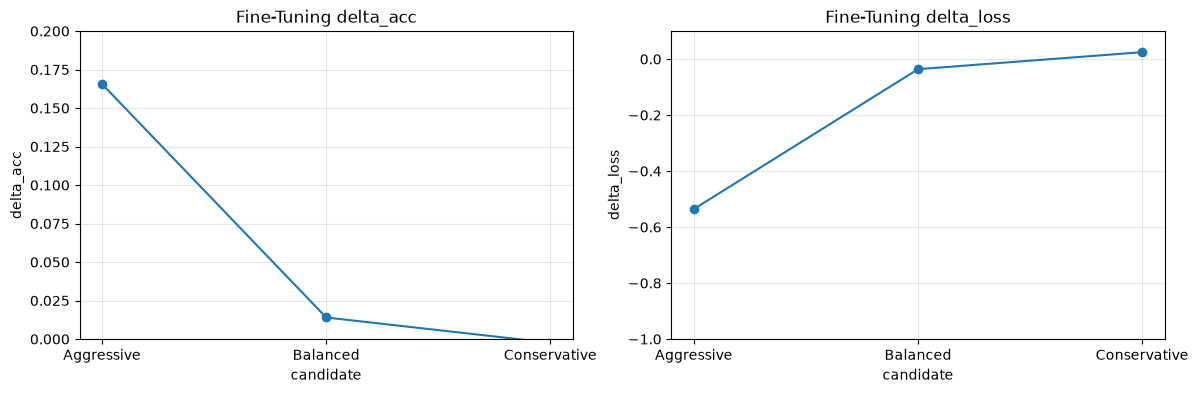

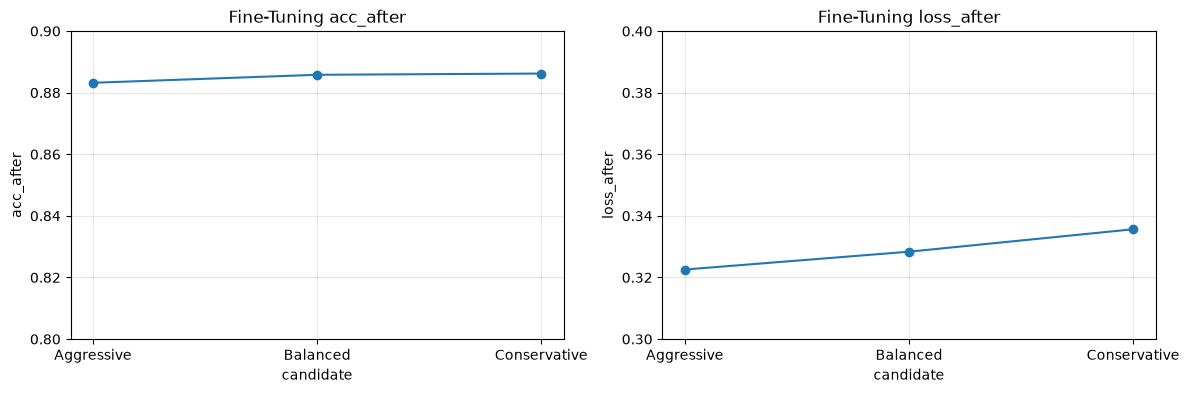

In [37]:
# ============================================================
# Fine-tuning 前後の比較
# ------------------------------------------------------------
# Before:
#   02 の rank 選択で使った validation_loader_rank 上の性能
# After:
#   Fine-tuning 後の best state を validation_loader_rank で再評価した性能
#
# delta_acc  = acc_after  - acc_before   （正なら改善）
# delta_loss = loss_after - loss_before  （負なら改善）
# ============================================================

fine_tuning_records = []

for idx, pareto_row in df_pareto_best.iterrows():
    fc1_rank = int(pareto_row["fc1_rank"])
    fc2_rank = int(pareto_row["fc2_rank"])

    # Pareto frontier 上で knee より左 / knee / 右
    if idx < knee_pos:
        candidate = "Aggressive"
    elif idx == knee_pos:
        candidate = "Balanced"
    else:
        candidate = "Conservative"

    # Fine-tuning 前:
    # rank sweep 時に validation_loader_rank で求めた値をそのまま使う
    acc_before = float(pareto_row["validation_acc"])
    loss_before = float(pareto_row["validation_loss"])

    # 同じ rank の Fine-tuning 済みモデルを取得
    matched = df_re_baseline_state[
        (df_re_baseline_state["fc1_rank"] == fc1_rank)
        & (df_re_baseline_state["fc2_rank"] == fc2_rank)
    ]

    if len(matched) != 1:
        raise ValueError(
            f"Fine-tuning 済みモデルが一意に見つかりません: "
            f"r1={fc1_rank}, r2={fc2_rank}, matches={len(matched)}"
        )

    fine_tuned_model = matched.iloc[0]["model"]

    # Fine-tuning 後:
    # Early Stopping 用 validation_loader ではなく、
    # Before と同じ validation_loader_rank で比較する
    loss_after, acc_after = evaluate(
        fine_tuned_model,
        validation_loader_rank,
        criterion,
        device,
    )

    fine_tuning_records.append(
        {
            "candidate": candidate,
            "fc1_rank": fc1_rank,
            "fc2_rank": fc2_rank,
            "acc_before": acc_before,
            "acc_after": acc_after,
            "delta_acc": acc_after - acc_before,
            "loss_before": loss_before,
            "loss_after": loss_after,
            "delta_loss": loss_after - loss_before,
        }
    )

df_fine_tuning_result = pd.DataFrame(fine_tuning_records)
fig_delta, axes_delta = plt.subplots(1, 2, figsize=(14, 4))
axes_delta[0].plot(
    df_fine_tuning_result["candidate"],
    df_fine_tuning_result["delta_acc"],
    marker="o",
)
axes_delta[0].set_xlabel("candidate")
axes_delta[0].set_ylabel("delta_acc")
axes_delta[0].set_ylim(0.0, 0.2)
axes_delta[0].set_title("Fine-Tuning delta_acc")
axes_delta[0].grid(True, alpha=0.3)

axes_delta[1].plot(
    df_fine_tuning_result["candidate"],
    df_fine_tuning_result["delta_loss"],
    marker="o",
)
axes_delta[1].set_xlabel("candidate")
axes_delta[1].set_ylabel("delta_loss")
axes_delta[1].set_ylim(-1.0, 0.1)
axes_delta[1].set_title("Fine-Tuning delta_loss")
axes_delta[1].grid(True, alpha=0.3)

fig_after, axes_after = plt.subplots(1, 2, figsize=(14, 4))
axes_after[0].plot(
    df_fine_tuning_result["candidate"],
    df_fine_tuning_result["acc_after"],
    marker="o",
)
axes_after[0].set_xlabel("candidate")
axes_after[0].set_ylabel("acc_after")
axes_after[0].set_ylim(0.8, 0.9)
axes_after[0].set_title("Fine-Tuning acc_after")
axes_after[0].grid(True, alpha=0.3)

axes_after[1].plot(
    df_fine_tuning_result["candidate"],
    df_fine_tuning_result["loss_after"],
    marker="o",
)
axes_after[1].set_xlabel("candidate")
axes_after[1].set_ylabel("loss_after")
axes_after[1].set_ylim(0.3, 0.4)
axes_after[1].set_title("Fine-Tuning loss_after")
axes_after[1].grid(True, alpha=0.3)
display(df_fine_tuning_result)


In [32]:
# ============================================================
# Baseline / Fine-tuning 後3候補の比較表
# ============================================================

# Fine-tuning後の結果に、02で求めたパラメータ情報を対応付ける
df_candidate_params = df_pareto_best[
    ["fc1_rank", "fc2_rank", "parameters", "parameters_reduction"]
].copy()

df_after_comparison = df_fine_tuning_result.merge(
    df_candidate_params,
    on=["fc1_rank", "fc2_rank"],
    how="left",
    validate="one_to_one",
)

comparison_records = [
    {
        "model": "Baseline",
        "fc1_rank": "-",
        "fc2_rank": "-",
        "validation_acc": baseline_rank_validation_acc,
        "validation_loss": baseline_rank_validation_loss,
        "parameters": baseline_params,
        "parameters_reduction": 0.0,
    }
]

for _, row in df_after_comparison.iterrows():
    comparison_records.append(
        {
            "model": f"{row['candidate']} after FT",
            "fc1_rank": int(row["fc1_rank"]),
            "fc2_rank": int(row["fc2_rank"]),
            "validation_acc": row["acc_after"],
            "validation_loss": row["loss_after"],
            "parameters": int(row["parameters"]),
            "parameters_reduction": row["parameters_reduction"],
        }
    )

df_model_comparison = pd.DataFrame(comparison_records)
display(df_model_comparison)


,model,fc1_rank,fc2_rank,validation_acc,validation_loss,parameters,parameters_reduction
0,Baseline,-,-,0.8942,0.299003,535818,0.000000
1,Aggressive after FT,16,16,0.8832,0.322567,36362,0.932137
2,Balanced after FT,32,16,0.8858,0.328358,57098,0.893438
3,Conservative after FT,64,16,0.8862,0.335646,98570,0.816038


In [33]:
# ============================================================
# Fine-tuning後の最終モデルを機械的に選択
#
# 1. parameters と validation_loss で Pareto frontier を作る
# 2. Pareto候補が複数残った場合:
#       validation_loss が小さいものを優先
# 3. loss が同じなら:
#       parameters が少ないものを優先
# 4. それも同じなら:
#       validation_acc が高いものを優先
# ============================================================

# Baselineは最終圧縮モデルの選択対象から除外
df_final_candidates = df_model_comparison[
    df_model_comparison["model"] != "Baseline"
].copy()


# ------------------------------------------------------------
# Pareto frontier 抽出
# parameters      : 小さいほど良い
# validation_loss : 小さいほど良い
# ------------------------------------------------------------
keep_indices = []

for index, row in df_final_candidates.iterrows():

    dominated = (
        (df_final_candidates["parameters"] <= row["parameters"])
        & (df_final_candidates["validation_loss"] <= row["validation_loss"])
        & (
            (df_final_candidates["parameters"] < row["parameters"])
            | (
                df_final_candidates["validation_loss"]
                < row["validation_loss"]
            )
        )
    )

    if not dominated.any():
        keep_indices.append(index)


df_final_pareto = (
    df_final_candidates
    .loc[keep_indices]
    .copy()
)

print("Fine-tuning後のPareto候補:")
display(df_final_pareto)


# ------------------------------------------------------------
# Pareto候補から最終モデルを1つ選択
#
# 優先順位:
#   1. validation_loss が小さい
#   2. parameters が少ない
#   3. validation_acc が高い
# ------------------------------------------------------------
df_final_pareto = df_final_pareto.sort_values(
    by=[
        "validation_loss",
        "parameters",
        "validation_acc",
    ],
    ascending=[
        True,   # loss: 小さい方
        True,   # parameters: 少ない方
        False,  # accuracy: 大きい方
    ],
).reset_index(drop=True)


final_model_result = df_final_pareto.iloc[0]

print("Selected final model:")
display(df_final_pareto.iloc[[0]])


# ------------------------------------------------------------
# Fine-tuning済みPyTorchモデル本体を取得
# ------------------------------------------------------------
final_fc1_rank = int(final_model_result["fc1_rank"])
final_fc2_rank = int(final_model_result["fc2_rank"])

final_model = df_re_baseline_state.loc[
    (df_re_baseline_state["fc1_rank"] == final_fc1_rank)
    & (df_re_baseline_state["fc2_rank"] == final_fc2_rank),
    "model",
].iloc[0]

print(
    f"Final model: "
    f"r1={final_fc1_rank}, "
    f"r2={final_fc2_rank}"
)

Fine-tuning後のPareto候補:


,model,fc1_rank,fc2_rank,validation_acc,validation_loss,parameters,parameters_reduction
1,Aggressive after FT,16,16,0.8832,0.322567,36362,0.932137


Selected final model:


,model,fc1_rank,fc2_rank,validation_acc,validation_loss,parameters,parameters_reduction
0,Aggressive after FT,16,16,0.8832,0.322567,36362,0.932137


Final model: r1=16, r2=16


In [34]:
# 最良重みに戻した後でTestデータを評価する
test_loss, test_acc = evaluate(
    final_model,
    test_loader,
    criterion,
    device,
)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Test loss: 0.3662
Test accuracy: 0.8714


In [35]:
# ============================================================
# Test 結果の比較表: Baseline vs Final (圧縮+FT後)
# ------------------------------------------------------------
# final 側は直前セルの test_loss / test_acc を使う
# baseline 側は baseline_state を読み込んで test_loader で評価
# ============================================================

# Baseline を Test で評価（選択には使わず、最終報告用）
_baseline_model_for_test = copy.deepcopy(model)
_baseline_model_for_test.load_state_dict(baseline_state)
baseline_test_loss, baseline_test_acc = evaluate(
    _baseline_model_for_test,
    test_loader,
    criterion,
    device,
)

df_test_comparison = pd.DataFrame(
    [
        {
            "model": "Baseline",
            "fc1_rank": "-",
            "fc2_rank": "-",
            "parameters": int(baseline_params) if "baseline_params" in globals() else count_parameters(_baseline_model_for_test),
            "test_loss": baseline_test_loss,
            "test_acc": baseline_test_acc,
            "delta_test_acc": 0.0,
            "delta_test_loss": 0.0,
        },
        {
            "model": "Final (compressed + FT)",
            "fc1_rank": int(final_fc1_rank),
            "fc2_rank": int(final_fc2_rank),
            "parameters": count_parameters(final_model),
            "test_loss": test_loss,
            "test_acc": test_acc,
            "delta_test_acc": test_acc - baseline_test_acc,   # + なら精度向上
            "delta_test_loss": test_loss - baseline_test_loss,  # - なら損失改善
        },
    ]
)

print("Test comparison (Baseline vs Final):")
display(df_test_comparison)


Test comparison (Baseline vs Final):


,model,fc1_rank,fc2_rank,parameters,test_loss,test_acc,delta_test_acc,delta_test_loss
0,Baseline,-,-,535818,0.333783,0.8871,0.0000,0.000000
1,Final (compressed + FT),16,16,36362,0.366167,0.8714,-0.0157,0.032384


In [36]:
# ============================================================
# 結果の保存（03 Fine-tuning）
# ------------------------------------------------------------
# CSV
#   fine_tuning_result.csv   … Before/After・delta（df_fine_tuning_result）
#   model_comparison.csv     … Baseline と FT 後3候補（df_model_comparison）
#   selected_final_model.csv … 機械選択された最終モデルのメタ情報
# 図
#   fine_tuning_delta.png    … delta_acc / delta_loss
#   fine_tuning_after.png    … acc_after / loss_after
# モデル
#   r1*_r2*_final.pt         … 最終選択モデルの重み
# ============================================================
results_dir.mkdir(parents=True, exist_ok=True)

# --- CSV ---
fine_tuning_result_path = results_dir / "fine_tuning_result.csv"
model_comparison_path = results_dir / "model_comparison.csv"

df_fine_tuning_result.to_csv(fine_tuning_result_path, index=False)
df_model_comparison.to_csv(model_comparison_path, index=False)

# --- 図 ---
# NG（旧）: Pareto 用の fig だけ保存していた
# figure_path = results_dir / "parameters_vs_validation_loss_normalize.png"
# if "fig" in globals():
#     fig.savefig(figure_path, dpi=150, bbox_inches="tight")

delta_fig_path = results_dir / "fine_tuning_delta.png"
after_fig_path = results_dir / "fine_tuning_after.png"

if "fig_delta" not in globals():
    raise NameError("fig_delta がありません。比較グラフセルを先に実行してください。")
if "fig_after" not in globals():
    raise NameError("fig_after がありません。比較グラフセルを先に実行してください。")

fig_delta.savefig(delta_fig_path, dpi=150, bbox_inches="tight")
fig_after.savefig(after_fig_path, dpi=150, bbox_inches="tight")

# --- Fine-tuning 後モデル（候補すべて）---
models_dir.mkdir(parents=True, exist_ok=True)
saved_model_paths = []
if "df_re_baseline_state" in globals():
    for _, row in df_re_baseline_state.iterrows():
        r1 = int(row["fc1_rank"])
        r2 = int(row["fc2_rank"])
        matched = df_fine_tuning_result[
            (df_fine_tuning_result["fc1_rank"] == r1)
            & (df_fine_tuning_result["fc2_rank"] == r2)
        ]
        tag = str(matched.iloc[0]["candidate"]).lower() if len(matched) == 1 else "ft"
        model_path = models_dir / f"r1-{r1}_r2-{r2}_{tag}_finetuned.pt"
        torch.save(row["model"].state_dict(), model_path)
        saved_model_paths.append(model_path)

# --- 最終選択モデル（機械選択セルの final_model）---
if "final_model" not in globals():
    raise NameError(
        "final_model がありません。最終モデル選択セルを先に実行してください。"
    )

final_model_csv_path = results_dir / "selected_final_model.csv"
final_model_pt_path = (
    models_dir
    / f"r1-{final_fc1_rank}_r2-{final_fc2_rank}_final.pt"
)

# メタ情報（1行）
pd.DataFrame([final_model_result]).to_csv(final_model_csv_path, index=False)

# 重み
torch.save(final_model.state_dict(), final_model_pt_path)

print(f"saved fine_tuning_result: {fine_tuning_result_path}")
print(f"saved model_comparison:   {model_comparison_path}")
print(f"saved delta figure:       {delta_fig_path}")
print(f"saved after figure:       {after_fig_path}")
print(f"saved final model csv:    {final_model_csv_path}")
print(f"saved final model pt:     {final_model_pt_path}")
for path in saved_model_paths:
    print(f"saved model:              {path}")


saved fine_tuning_result: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\03_mlp_svd_finetuning\fine_tuning_result.csv
saved model_comparison:   D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\03_mlp_svd_finetuning\model_comparison.csv
saved delta figure:       D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\03_mlp_svd_finetuning\fine_tuning_delta.png
saved after figure:       D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\03_mlp_svd_finetuning\fine_tuning_after.png
saved final model csv:    D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\03_mlp_svd_finetuning\selected_final_model.csv
saved final model pt:     D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\03_mlp_svd_finetuning\r1-16_r2-16_final.pt
saved model:              D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\03_mlp_svd_finetuning\r1-16_r2-16_aggressive_finetuned.pt
saved model:              D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\03_mlp_svd_finetuning\r